# Fender Discussion — Operating Range on Force–Displacement Curve

For each of the six fenders, extracts the force time series from every heading and sea state, then overlays the activation interval $[F_{\min},\, F_{\max}]$ and mean force on the nonlinear force–displacement curve.
The goal is to assess whether the fender operates in a region where a linear stiffness approximation is valid.

In [ ]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': r'$0^\circ$', '45deg': r'$45^\circ$', '90deg': r'$90^\circ$',
                  '135deg': r'$135^\circ$', '180deg': r'$180^\circ$'}
HEADING_COLORS = {'0deg': '#1f77b4', '45deg': '#ff7f0e', '90deg': '#2ca02c',
                  '135deg': '#d62728', '180deg': '#9467bd'}
FENDER_ELEMS   = [f'Fender{i}' for i in range(1, 7)]
FENDER_POS_M   = {'Fender1': -50, 'Fender2': -30, 'Fender3': -10,
                  'Fender4':  10, 'Fender5':  30, 'Fender6':  50}

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
g         = 9.81
N_COND    = 10
HS_VALUES = np.linspace(0.5, 3.5, N_COND)

_B = 'BerthedTanker_Catenary'

LINES = {
    'HL7':  {'n': 7,  'base': f'{_B}/Run1',
             'dynamic': 'HL7/DynamicResults_HL7_run1-1.h5',   'n_cond': 9},
    'HL9':  {'n': 9,  'base': f'{_B}/Run2',
             'dynamic': 'HL9/DynamicResults_HL9_run2-1.h5',   'n_cond': 9},
    'HL11': {'n': 11, 'base': f'{_B}/Run3',
             'dynamic': 'HL11/DynamicResults_HL11_run3-1.h5', 'n_cond': 9},
    'HL13': {'n': 13, 'base': f'{_B}/Run4',
             'dynamic': 'HL13/DynamicResults_HL13_run4-1.h5', 'n_cond': 9},
    'HL15': {'n': 15, 'base': f'{_B}/Run5',
             'dynamic': 'HL15/DynamicResults_HL15_run5-1.h5', 'n_cond': 9},
    'HL17': {'n': 17, 'base': f'{_B}/Run6',
             'dynamic': 'HL17/DynamicResults_HL17_run6-1.h5', 'n_cond': 9},
    'HL19': {'n': 19, 'base': f'{_B}/Run7',
             'dynamic': 'HL19/DynamicResults_HL19_run7-1.h5', 'n_cond': 9},
    'HL21': {'n': 21, 'base': f'{_B}/Run8',
             'dynamic': 'HL21/DynamicResults_HL21_run8-1.h5', 'n_cond': 9},
    'HL23': {'n': 23, 'base': f'{_B}/Run9',
             'dynamic': 'HL23/DynamicResults_HL23_run9-1.h5', 'n_cond': 9},
    'HL25': {'n': 25, 'base': f'{_B}/Run10',
             'dynamic': 'HL25/DynamicResults_HL25_run10-1.h5','n_cond': 8},
    'HL27': {'n': 27, 'base': f'{_B}/Run11',
             'dynamic': 'HL27/DynamicResults_HL27_run11-1.h5','n_cond': 7},
    'HL29': {'n': 29, 'base': f'{_B}/Run12',
             'dynamic': 'HL29/DynamicResults_HL29_run12-1.h5','n_cond': 7},
}

for cfg in LINES.values():
    nc      = cfg['n_cond']
    Hs_vals = HS_VALUES[:nc]
    Tp_vals = np.sqrt(Hs_vals * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {
        i + 1: (round(float(hs), 2), round(float(tp), 2))
        for i, (hs, tp) in enumerate(zip(Hs_vals, Tp_vals))
    }

In [3]:
# Force-displacement curve for a single fender (absolute compression, kN)
FENDER_DISP_M  = np.array([0.00, 0.25, 0.50, 0.75, 0.95, 1.00,
                            1.25, 1.50, 1.75, 1.95, 2.05, 2.25, 2.50])
FENDER_FORCE_KN = np.array([0.0,  818.18, 1242.4, 1393.9, 1272.0, 1272.0,
                             1620.5, 2000.0, 1930.3, 1808.3, 1808.3, 2822.7, 5053.0])

In [4]:
delta_single = 0.03                          # static equilibrium compression per fender [m]
delta_op     = delta_single                  # operating deflection per fender [m]
F_op_N       = np.interp(delta_op, FENDER_DISP_M, FENDER_FORCE_KN * 1e3)
K_FENDER_KN  = (F_op_N / delta_op) / 1e3    # secant stiffness [kN/m]
print(f'k_fender = {K_FENDER_KN:.1f} kN/m')

k_fender = 3272.7 kN/m


## Load per-fender force statistics

For every heading, steepness line, condition, and random seed, extract the per-fender force time series
and compute $F_{\min}$, $F_{\max}$, and $F_{\text{mean}}$ (forces clipped at zero — fenders are compression-only).

In [5]:
rows = []

for heading in HEADINGS:
    print('=== ' + heading + ' ===')
    for line_name, cfg in LINES.items():
        dyn_base  = f'{heading}/{cfg["dynamic"]}'.rsplit('-', 1)[0]
        dyn_files = sorted(
            glob.glob(f'{dyn_base}-*.h5'),
            key=lambda p: int(p.rsplit('-', 1)[-1].replace('.h5', ''))
        )
        run_key = cfg['base'].split('/')[-1]

        if not dyn_files:
            continue

        seed_data = {}

        for dyn_file in dyn_files:
            try:
                with h5py.File(dyn_file, 'r') as fd:
                    root   = list(fd.keys())[0]
                    base_d = f'{root}/{run_key}'
                    for cond_key in fd[base_d].keys():
                        n   = int(cond_key.split('_')[-1])
                        grp = fd[f'{base_d}/{cond_key}/Dynamic/Tanker/Positioning system force']
                        for fdr in FENDER_ELEMS:
                            ts  = np.maximum(grp[f'TotalForce_{fdr}'][:], 0.0) / 1e3
                            key = (n, fdr)
                            if key not in seed_data:
                                seed_data[key] = {'maxes': [], 'mean_contacts': []}
                            seed_data[key]['maxes'].append(float(np.max(ts)))
                            contact = ts[ts > 0.0]
                            seed_data[key]['mean_contacts'].append(
                                float(np.mean(contact)) if contact.size > 0 else 0.0
                            )
            except FileNotFoundError:
                pass

        for (n, fdr), stats in seed_data.items():
            hs, tp = cfg['cond_params'].get(n, (np.nan, np.nan))
            rows.append({
                'heading':           heading,
                'line':              line_name,
                'cond_num':          n,
                'Hs':                hs,
                'fender':            fdr,
                'F_max_kN':          float(np.max(stats['maxes'])),
                'F_mean_contact_kN': float(np.mean(stats['mean_contacts'])),
            })

        print(f'  {line_name}: {len(dyn_files)} seed(s)')

df = pd.DataFrame(rows)
print(f'Total rows: {len(df)}')


=== 0deg ===


  HL7: 5 seed(s)


  HL9: 5 seed(s)


  HL11: 5 seed(s)


  HL13: 5 seed(s)


...

  HL21: 5 seed(s)


  HL23: 5 seed(s)


  HL25: 5 seed(s)


  HL27: 5 seed(s)


  HL29: 5 seed(s)
Total rows: 3090


In [6]:
# Envelope across all steepness lines and conditions, per (heading, fender)
envelope = (
    df.groupby(['heading', 'fender'])
    .agg(
        F_max_kN          = ('F_max_kN',          'max'),
        F_mean_contact_kN = ('F_mean_contact_kN',  'mean'),
    )
    .reset_index()
)
envelope


,heading,fender,F_max_kN,F_mean_contact_kN
0,0deg,Fender1,383.218292,141.715840
1,0deg,Fender2,311.024384,136.840577
2,0deg,Fender3,246.550430,131.935043
3,0deg,Fender4,186.232315,126.985160
4,0deg,Fender5,166.178009,122.030335
5,0deg,Fender6,185.578796,117.389263
6,135deg,Fender1,1671.522095,227.325700
7,135deg,Fender2,1651.422974,231.229726
8,135deg,Fender3,1658.350708,235.415516
9,135deg,Fender4,1654.173828,239.776574


In [7]:
def force_to_disp(F_kN):
    """Return fender compression (m) for a given force (kN) via linear interpolation.
    Returns the first (lowest-displacement) crossing. Extrapolates beyond 2.5 m if needed."""
    for i in range(len(FENDER_FORCE_KN) - 1):
        f0, f1 = FENDER_FORCE_KN[i], FENDER_FORCE_KN[i + 1]
        d0, d1 = FENDER_DISP_M[i],   FENDER_DISP_M[i + 1]
        lo, hi = min(f0, f1), max(f0, f1)
        if lo <= F_kN <= hi:
            t = (F_kN - f0) / (f1 - f0) if f1 != f0 else 0.0
            return d0 + t * (d1 - d0)
    if F_kN > FENDER_FORCE_KN[-1]:
        slope = ((FENDER_FORCE_KN[-1] - FENDER_FORCE_KN[-2]) /
                 (FENDER_DISP_M[-1]   - FENDER_DISP_M[-2]))
        return FENDER_DISP_M[-1] + (F_kN - FENDER_FORCE_KN[-1]) / slope
    return 0.0


## Operating range on the force–displacement curve

One figure per fender.  
The shaded band spans $[F_{\min},\, F_{\max}]$ across all sea states for a given heading — this is the full activation interval the fender exercises during the simulation campaign.  
The dashed line marks the mean force level ($F_{\text{mean}}$ averaged across conditions).  
If the activation interval sits in the quasi-linear portion of the curve, a frequency-domain (linear) model is a reasonable approximation for that fender.

In [8]:
def plot_fender_heading(fdr, heading):
    row = envelope[(envelope.fender == fdr) & (envelope.heading == heading)]
    if row.empty:
        return
    F_max    = float(row['F_max_kN'].iloc[0])
    F_mean_c = float(row['F_mean_contact_kN'].iloc[0])
    color    = HEADING_COLORS[heading]
    label    = HEADING_LABELS[heading]

    fig, ax = plt.subplots(figsize=full())
    ax.plot(FENDER_DISP_M, FENDER_FORCE_KN, 'k-', lw=2, zorder=5, label='Fender curve')
    ax.plot(FENDER_DISP_M, K_FENDER_KN * FENDER_DISP_M, 'k--', lw=1.2,
            label=f'Linear approx. ($k = {K_FENDER_KN:.0f}$ kN/m)')
    ax.axhspan(F_mean_c, F_max, alpha=0.25, color=color,
               label=f'{label} activation interval')
    ax.axhline(F_mean_c, color=color, lw=1.2, ls='--',
               label=f'{label} mean (loaded)')
    ax.axhline(F_max, color=color, lw=1.2, ls='-',
               label=f'{label} extreme')
    ax.set_xlabel('Compression (m)')
    ax.set_ylabel('Force (kN)')
    ax.set_xlim(0, 2.5)
    ax.set_ylim(bottom=0)
    ax.legend()
    plt.tight_layout()
    plt.show()


## Fender1 — $x = -50$ m

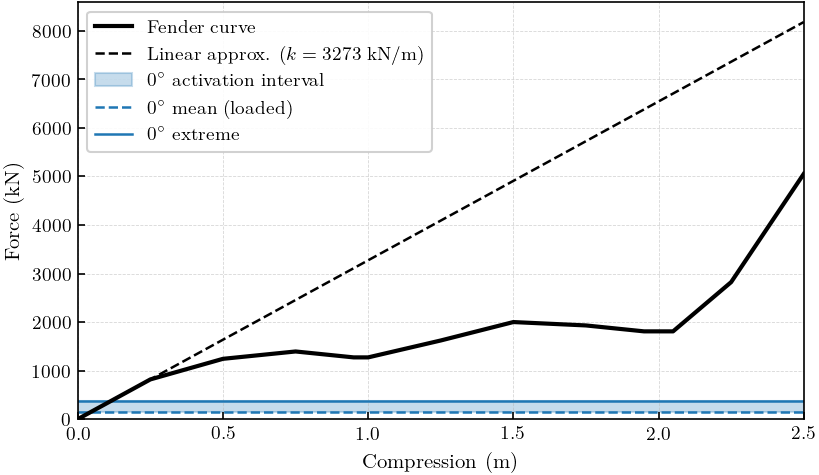

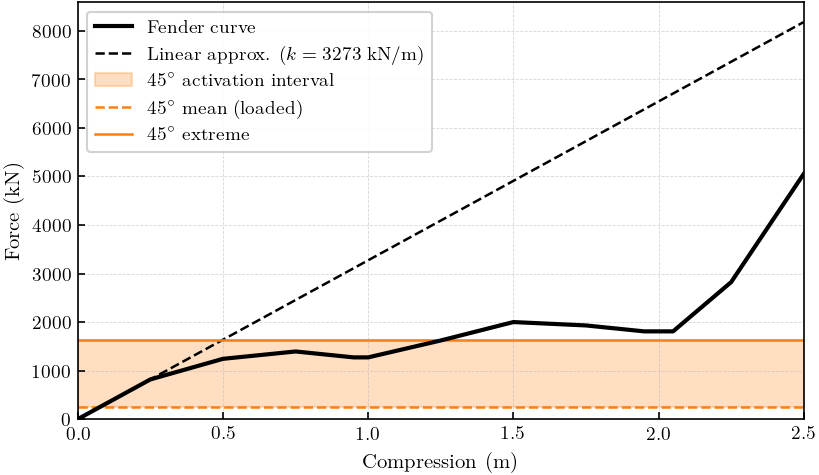

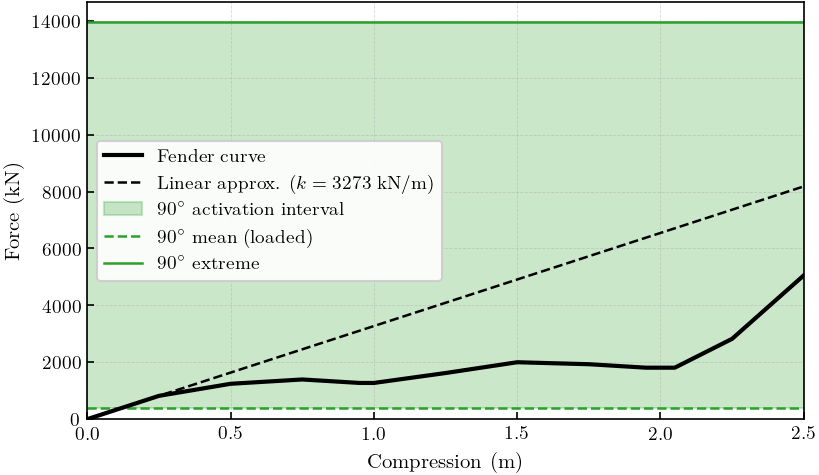

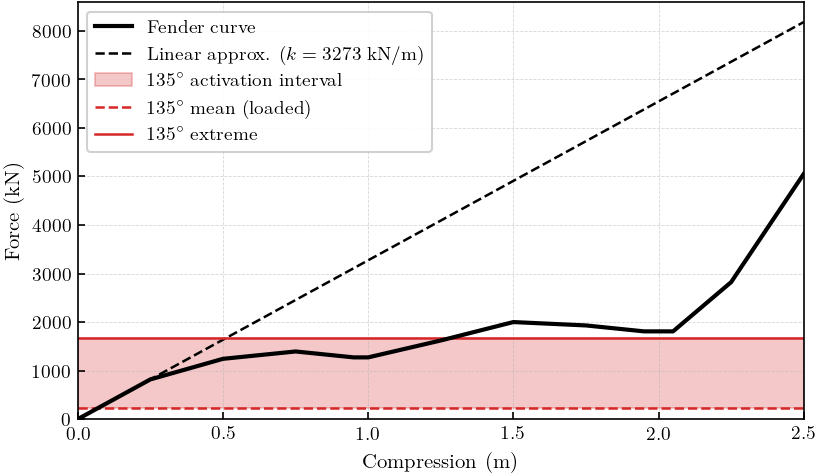

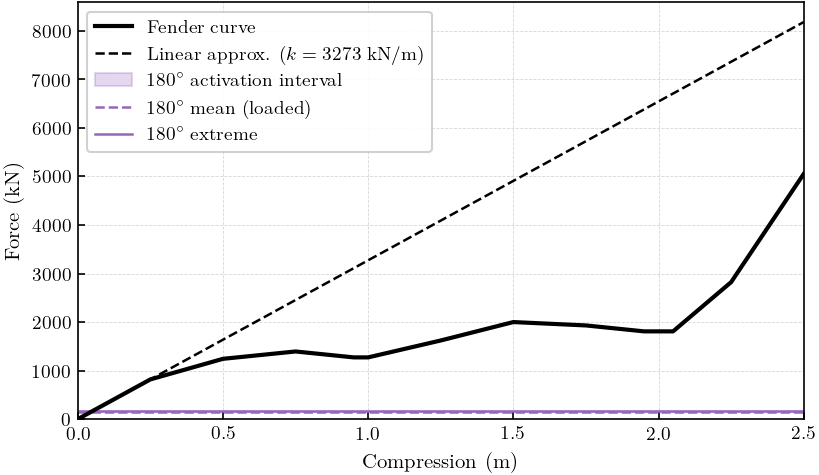

In [9]:
for h in HEADINGS:
    plot_fender_heading('Fender1', h)

## Fender2 — $x = -30$ m

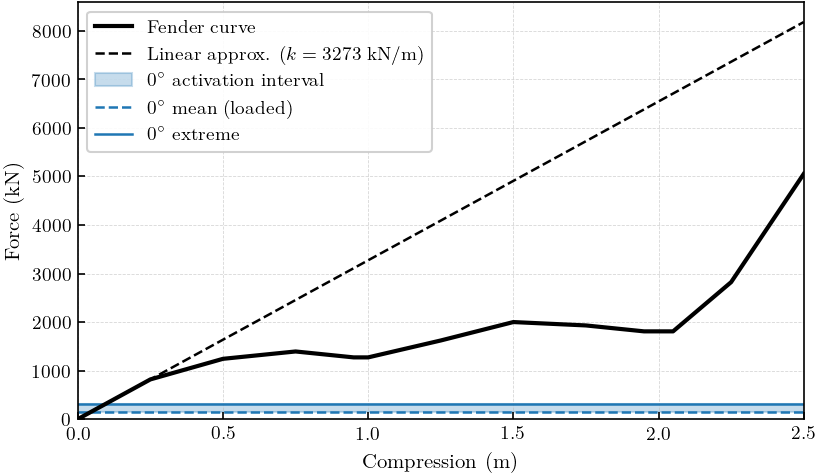

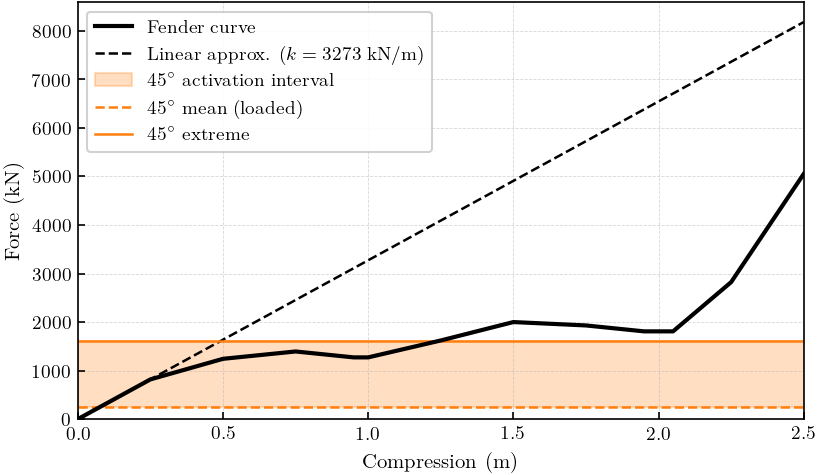

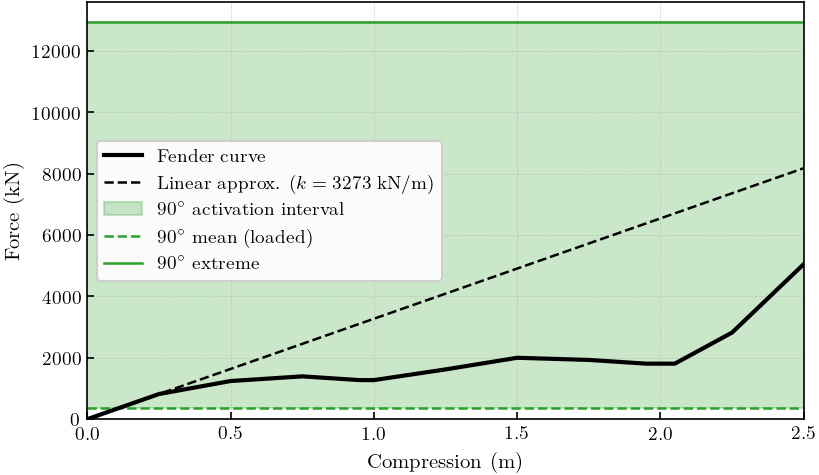

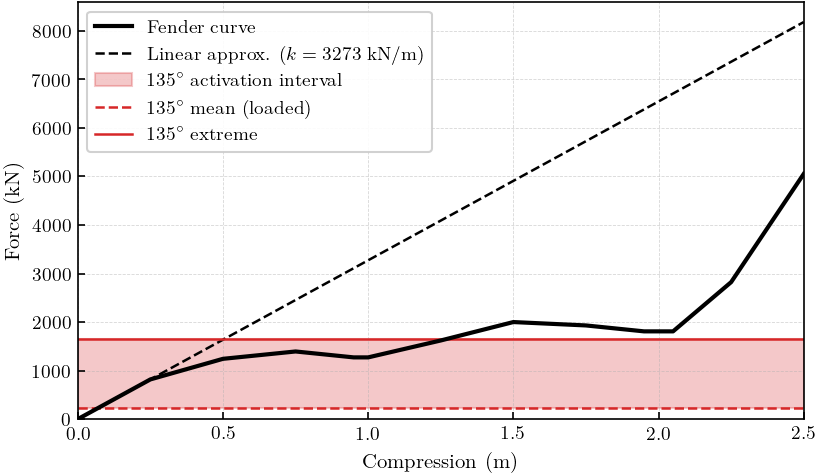

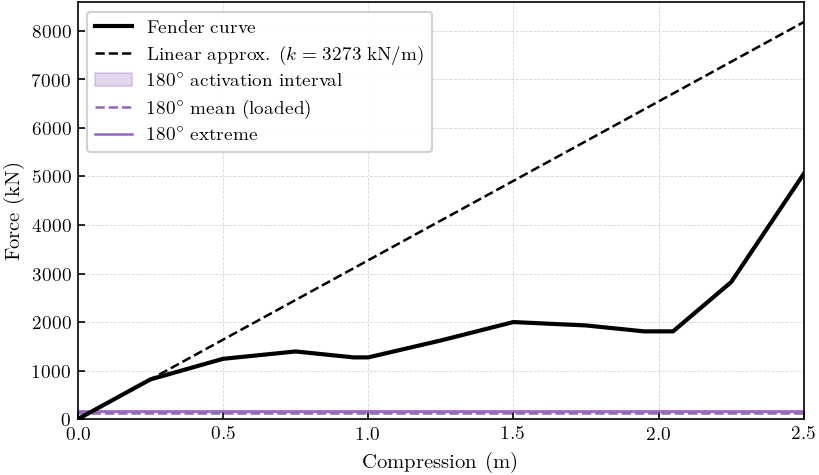

In [10]:
for h in HEADINGS:
    plot_fender_heading('Fender2', h)

## Fender3 — $x = -10$ m

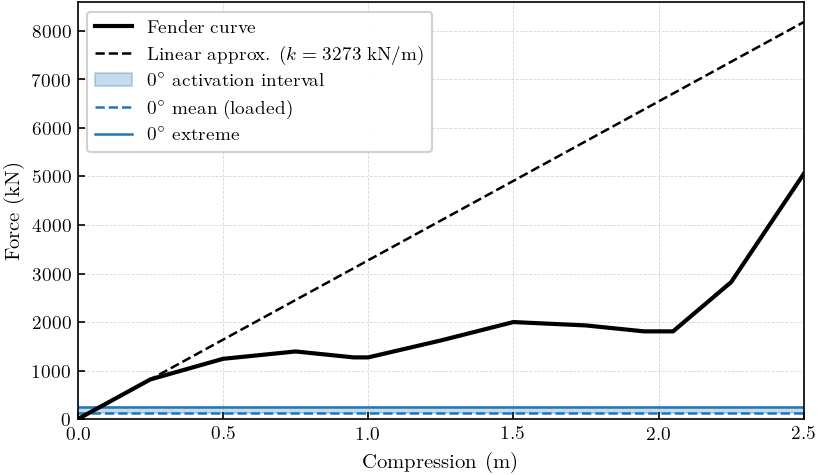

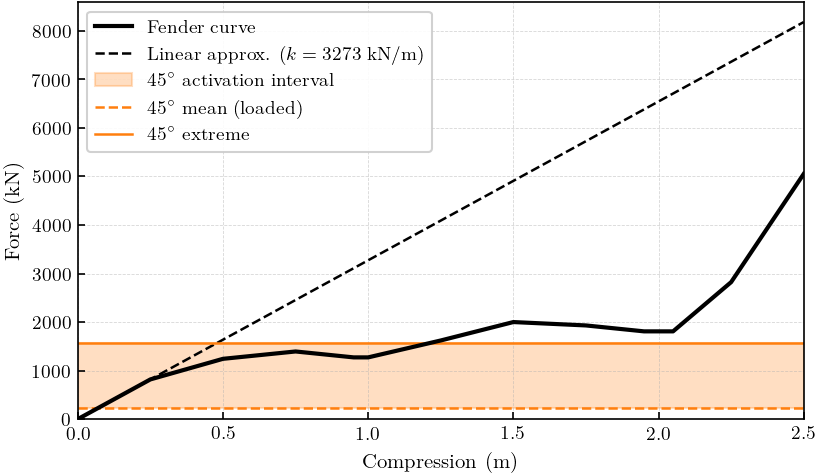

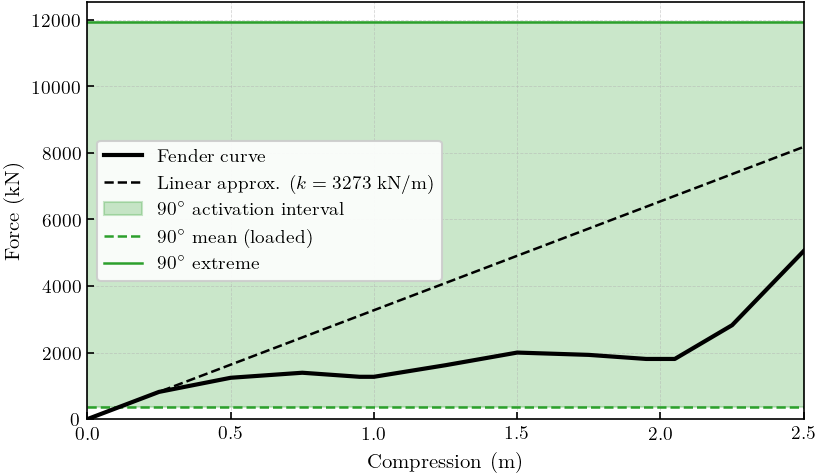

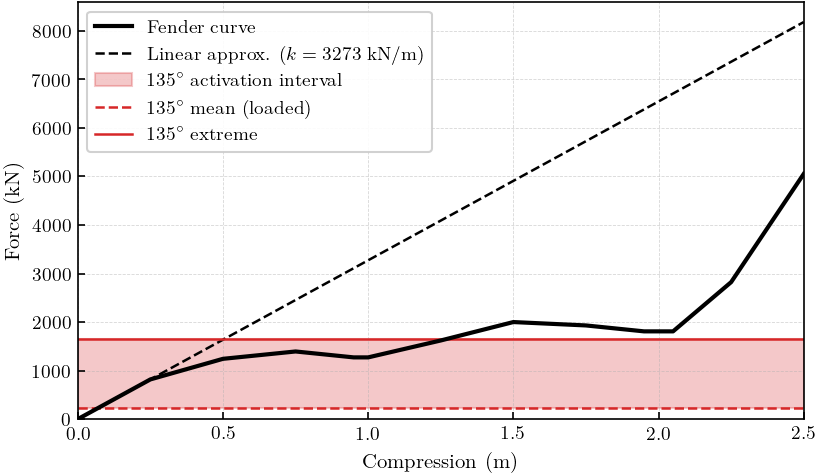

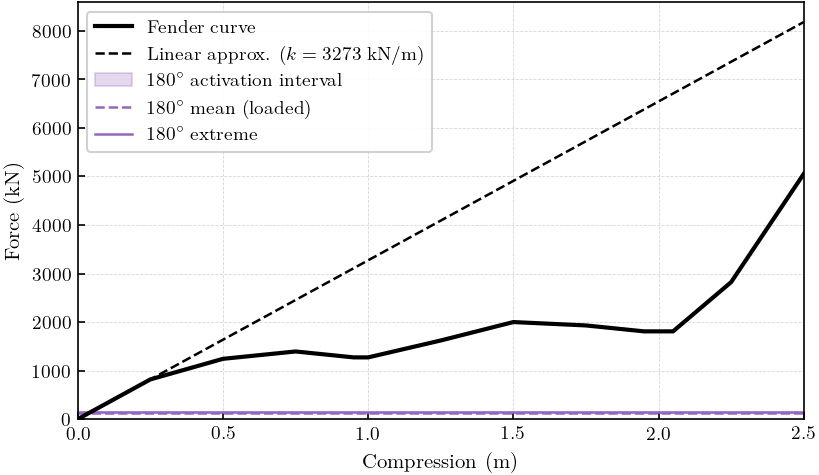

In [11]:
for h in HEADINGS:
    plot_fender_heading('Fender3', h)

## Fender4 — $x = 10$ m

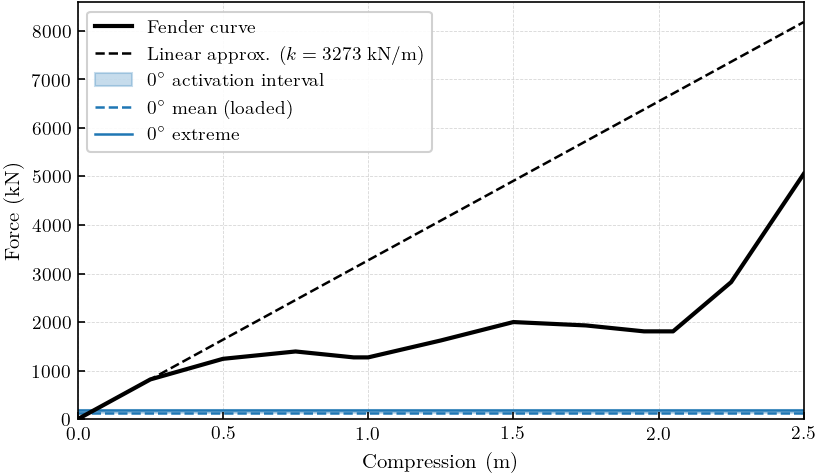

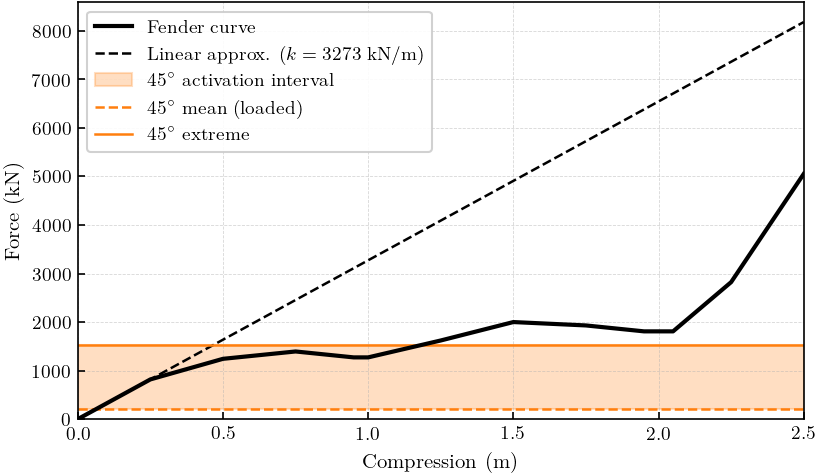

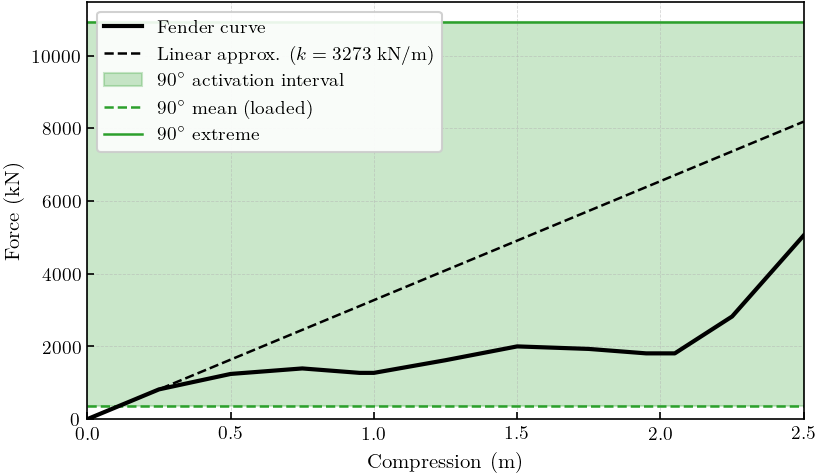

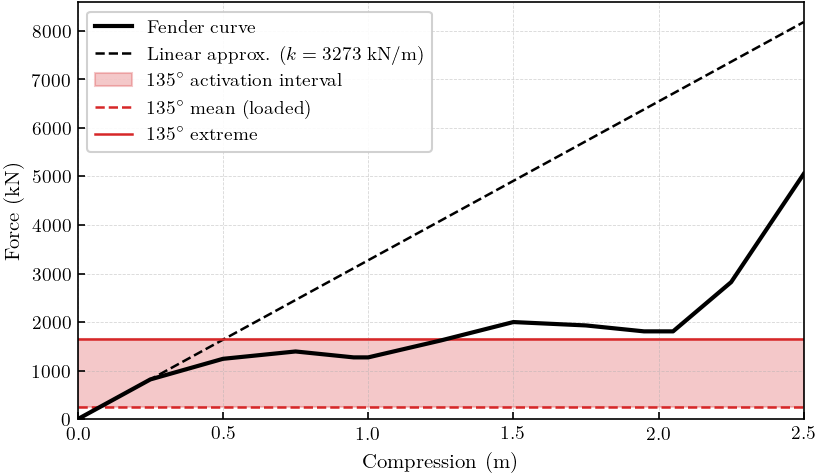

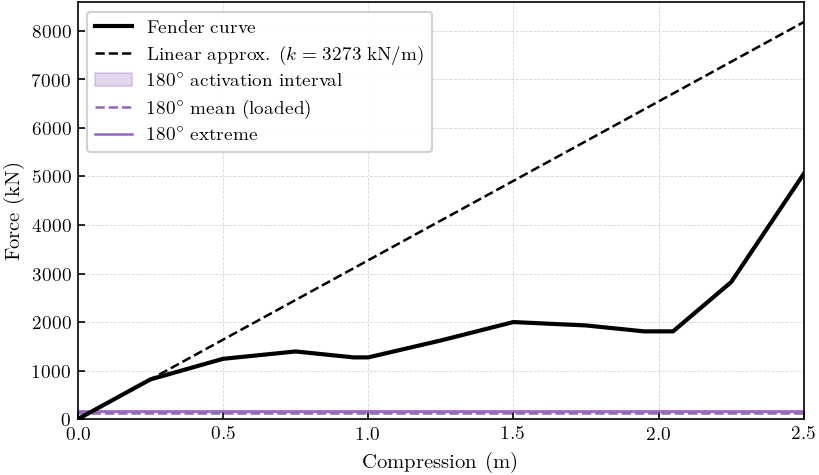

In [12]:
for h in HEADINGS:
    plot_fender_heading('Fender4', h)

## Fender5 — $x = 30$ m

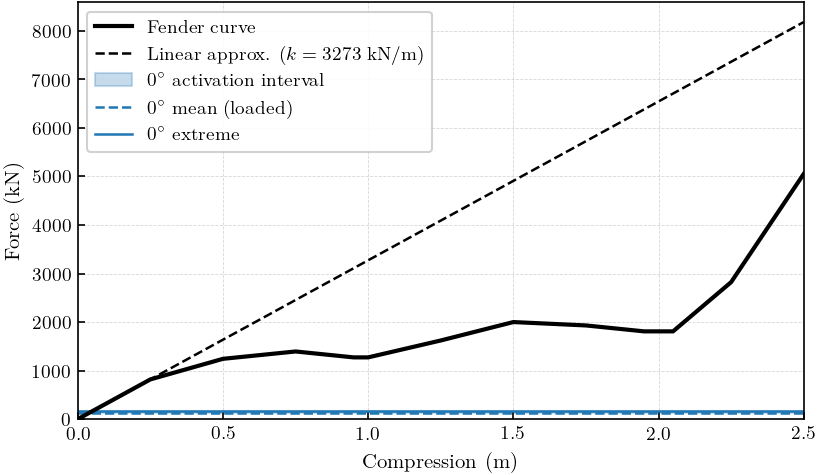

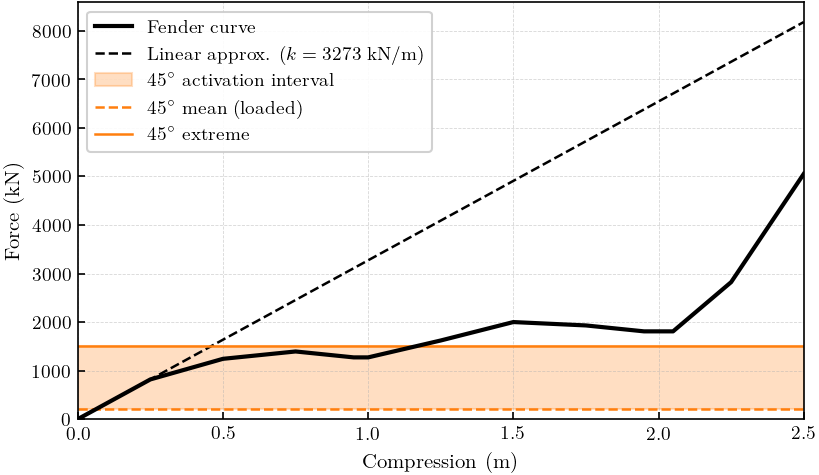

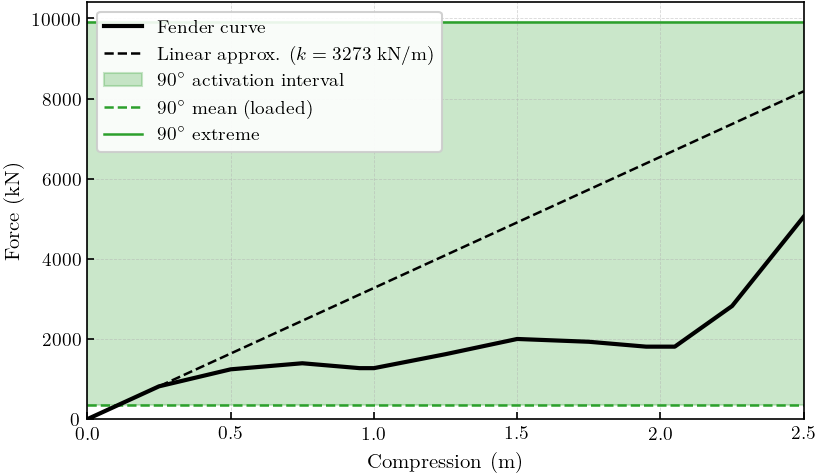

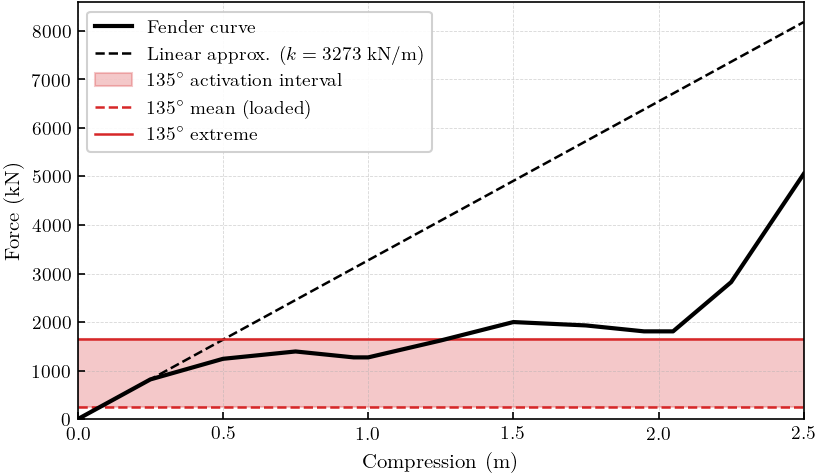

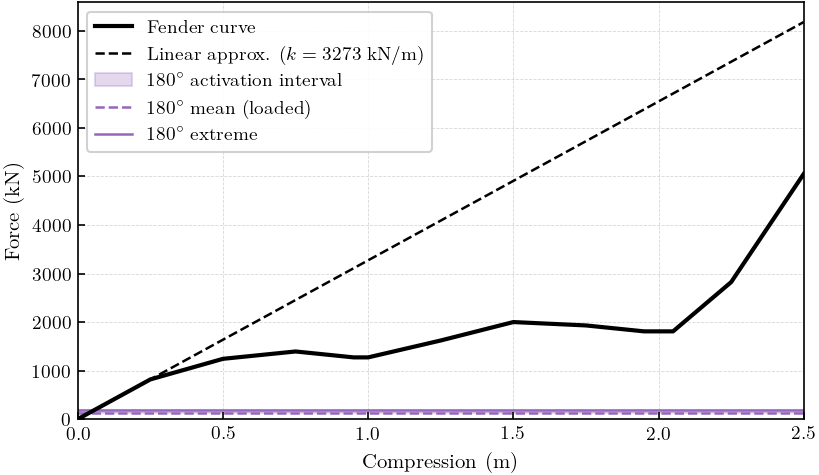

In [13]:
for h in HEADINGS:
    plot_fender_heading('Fender5', h)

## Fender6 — $x = 50$ m

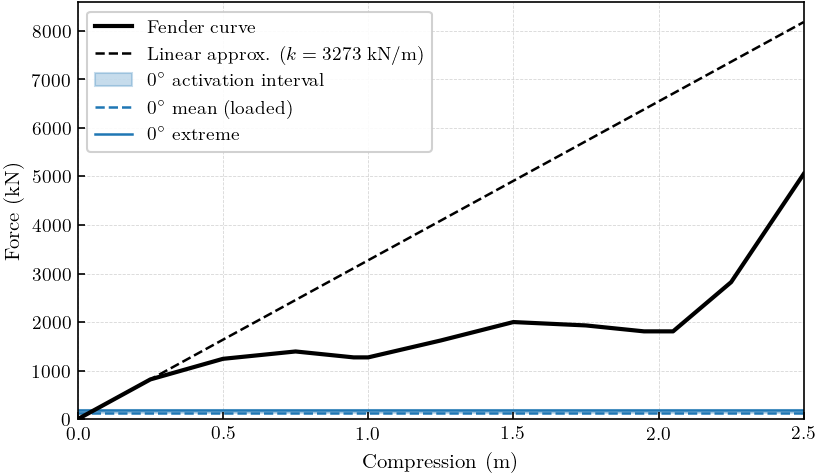

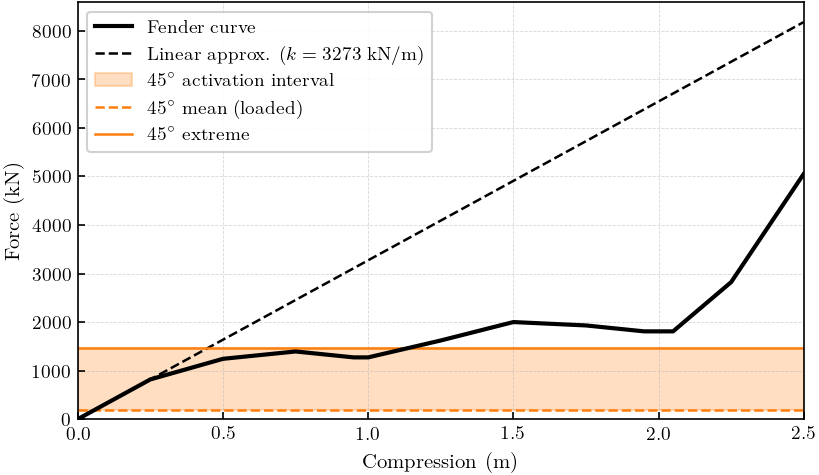

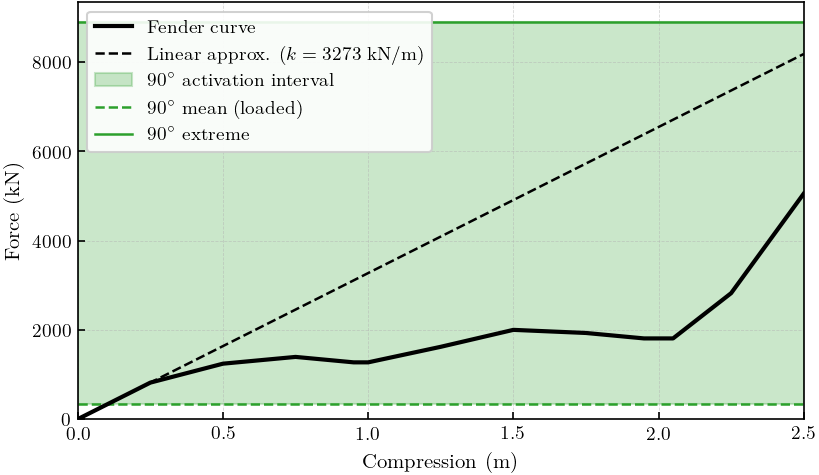

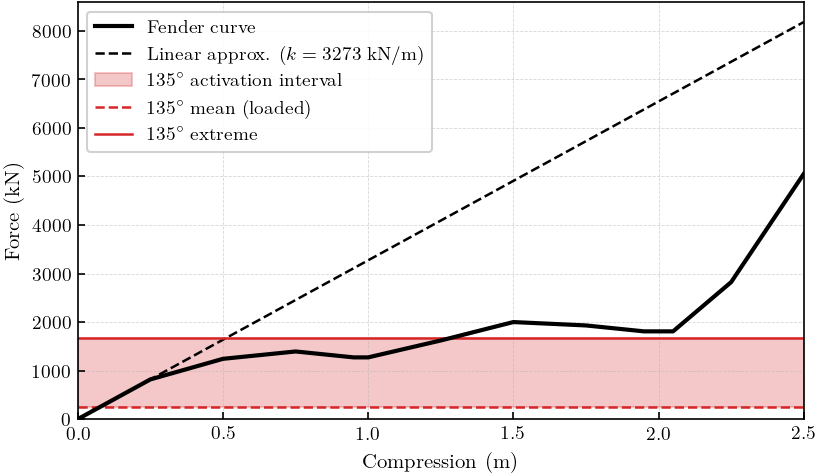

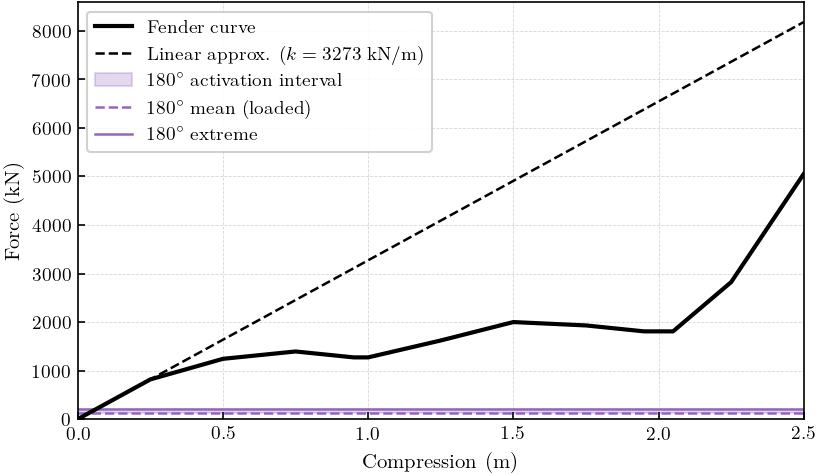

In [14]:
for h in HEADINGS:
    plot_fender_heading('Fender6', h)